In [25]:
import cv2, glob, random, os
import numpy as np
import matplotlib
import matplotlib.font_manager as fm
from PIL import Image, ImageDraw, ImageFont
from tensorflow import keras
from tensorflow.keras import layers
from google.colab import files
from google.colab.patches import cv2_imshow

In [26]:
# MNIST is handwritten, but Sudoku puzzles are usually printed.
# So we add synthetic printed digits to the training set.
# collect fonts (skip symbol/math fonts whose glyphs aren't normal digits)
font_files = set(fm.findSystemFonts(fontext="ttf"))
font_files |= set(glob.glob(matplotlib.get_data_path() + "/fonts/ttf/*.ttf"))
bad = ("cm", "dingbat", "symbol", "wingding", "emoji", "stixsizeonesym")
font_files = [f for f in font_files
              if not os.path.basename(f).lower().startswith(bad)
              and not any(b in f.lower() for b in ("dingbat", "symbol", "emoji"))]
print(len(font_files), "fonts found")

def render_digit(d, font_path):
    try:
        font = ImageFont.truetype(font_path, random.randint(40, 80))
    except Exception:
        return None
    im = Image.new("L", (140, 140), 0)
    ImageDraw.Draw(im).text((30, 15), str(d), fill=255, font=font)
    arr = np.array(im)

    # random thickness changes so thin and bold strokes are both covered
    k = random.choice([0, 0, 1, 2])
    if k == 1: arr = cv2.dilate(arr, np.ones((2, 2), np.uint8))
    if k == 2: arr = cv2.erode(arr, np.ones((2, 2), np.uint8))

    # small random rotation
    M = cv2.getRotationMatrix2D((70, 70), random.uniform(-4, 4), 1.0)
    arr = cv2.warpAffine(arr, M, (140, 140))

    arr = (arr > 100).astype(np.uint8) * 255      # same binarization idea as inference
    ys, xs = np.where(arr > 0)
    if len(ys) == 0:
        return None
    crop = arr[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    h, w = crop.shape
    s = 20 / max(h, w)
    crop = cv2.resize(crop, (max(1, int(w * s)), max(1, int(h * s))))
    canvas = np.zeros((28, 28), np.uint8)
    yo, xo = (28 - crop.shape[0]) // 2, (28 - crop.shape[1]) // 2
    canvas[yo:yo + crop.shape[0], xo:xo + crop.shape[1]] = crop
    return canvas

X, Y = [], []
for d in range(1, 10):
    n = 0
    while n < 2000:
        img = render_digit(d, random.choice(font_files))
        if img is not None:
            X.append(img); Y.append(d - 1); n += 1

X = np.array(X).astype("float32")[..., None] / 255.0
Y = np.array(Y)

model = keras.Sequential([
    layers.Input((28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Flatten(), layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dense(9, activation="softmax"),
])
model.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(X, Y, epochs=8, batch_size=128, validation_split=0.1)

40 fonts found
Epoch 1/8
127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9523 - loss: 0.2062 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 2/8
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 3/8
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 5.2421e-04 - val_accuracy: 1.0000 - val_loss: 3.9635e-04
Epoch 4/8
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 2.0179e-04 - val_accuracy: 1.0000 - val_loss: 3.8215e-04
Epoch 5/8
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 1.7628e-04 - val_accuracy: 1.0000 - val_loss: 5.1478e-04
Epoch 6/8
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9998 - loss: 5.0354e-04 - val_accuracy: 1.0000 - val_loss: 1.1248e-05
Epoch 7/8
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9994 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 3.1374e-04
Epoch 8/8
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accura

A small CNN takes a 28×28 white-on-black digit and outputs one of 9 classes (digits 1 to 9). Zero is excluded because an empty cell isn't a "0", it's
detected by the absence of ink. MNIST alone is handwritten, so it tends to struggle with printed puzzles. I added a few hundred synthetic printed digits per class, rendered with OpenCV fonts, which usually helps noticeably.

In [19]:
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)
    return gray, thresh

def find_grid(thresh):
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)
    for c in cnts[:5]:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            return approx.reshape(4, 2).astype(np.float32)
    return None

def order_points(pts):
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).ravel()
    # top-left, top-right, bottom-right, bottom-left
    return np.array([pts[np.argmin(s)], pts[np.argmin(d)],
                     pts[np.argmax(s)], pts[np.argmax(d)]], np.float32)

daptive thresholding turns the photo into a black-and-white image that copes with uneven lighting, better than a single global threshold. The grid is normally the largest contour that can be approximated by a quadrilateral (approxPolyDP with 4 points). order_points sorts the corners as top-left, top-right, bottom-right, bottom-left, which is needed for the next step.


In [20]:
CELL = 50
SIZE = CELL * 9

def extract_digit(cell):
    h, w = cell.shape
    m = int(0.15 * h)                      # trim leftover grid lines
    cell = cell[m:h - m, m:w - m]
    cnts, _ = cv2.findContours(cell, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    if cv2.contourArea(c) < 0.02 * cell.shape[0] * cell.shape[1]:
        return None                         # too little ink -> empty cell
    x, y, bw, bh = cv2.boundingRect(c)
    digit = cell[y:y + bh, x:x + bw]
    s = 20 / max(bw, bh)
    digit = cv2.resize(digit, (max(1, int(bw * s)), max(1, int(bh * s))))
    canvas = np.zeros((28, 28), np.uint8)   # center in 28x28 like MNIST
    yo, xo = (28 - digit.shape[0]) // 2, (28 - digit.shape[1]) // 2
    canvas[yo:yo + digit.shape[0], xo:xo + digit.shape[1]] = digit
    return canvas

def read_board(warped_gray):
    blur = cv2.GaussianBlur(warped_gray, (3, 3), 0)
    # digits are dark; thin grid lines and blue highlights are light
    _, wb = cv2.threshold(blur, 130, 255, cv2.THRESH_BINARY_INV)

    board = np.zeros((9, 9), int)
    crops, pos = [], []
    for r in range(9):
        for c in range(9):
            cell = wb[r*CELL:(r+1)*CELL, c*CELL:(c+1)*CELL]
            d = extract_digit(cell)
            if d is not None:
                crops.append(d)
                pos.append((r, c))
    if crops:
        Xc = np.array(crops).astype("float32")[..., None] / 255.0
        preds = model.predict(Xc, verbose=0).argmax(1) + 1
        for (r, c), p in zip(pos, preds):
            board[r, c] = p
    return board

For each cell, trim a margin to cut off leftover grid lines, find the biggest blob, and treat it as empty if it has too little ink. Otherwise crop the digit, scale it to fit 20×20, and center it in a 28×28 canvas, matching how MNIST digits are formatted. Then one batched model.predict call classifies them all.

In [21]:
def valid(b, r, c, n):
    if n in b[r] or n in b[:, c]:
        return False
    br, bc = 3 * (r // 3), 3 * (c // 3)
    return n not in b[br:br+3, bc:bc+3]

def solve(b):
    for r in range(9):
        for c in range(9):
            if b[r, c] == 0:
                for n in range(1, 10):
                    if valid(b, r, c, n):
                        b[r, c] = n
                        if solve(b):
                            return True
                        b[r, c] = 0
                return False
    return True

Find the first empty cell, try 1 to 9, and keep a number only if it doesn't conflict with its row, column, or 3×3 box. Recurse, and if you hit a dead end, reset the cell to 0 and backtrack. It's fast enough for any normal puzzle.

Saving sudoku.png to sudoku (4).png
Recognized board:
 [[9 0 0 5 0 8 0 0 7]
 [0 8 0 3 0 2 9 0 5]
 [0 5 4 0 0 0 0 8 0]
 [0 7 0 6 8 0 0 3 2]
 [1 0 0 0 0 4 0 0 8]
 [5 0 0 2 1 9 0 6 0]
 [0 0 0 9 0 6 0 0 1]
 [7 2 6 0 0 1 0 4 0]
 [0 0 1 4 7 0 0 5 6]]


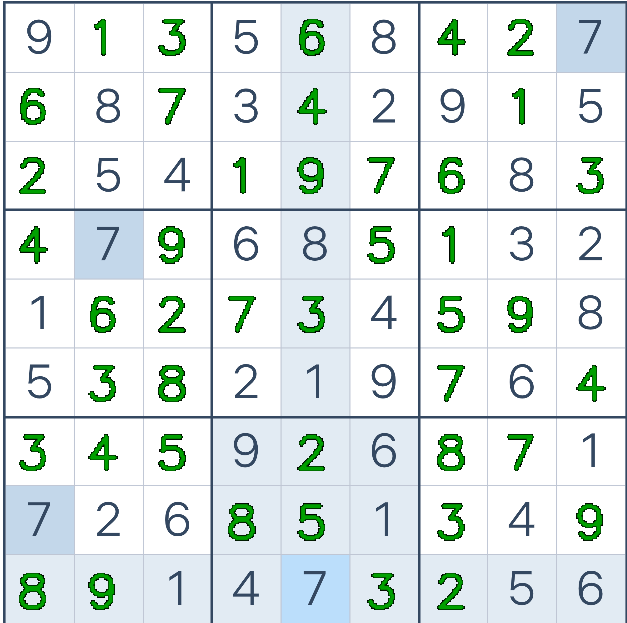

In [27]:
def solve_sudoku_image(img, already_cropped=True):
    H, W = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if already_cropped:
        corners = np.array([[0, 0], [W-1, 0], [W-1, H-1], [0, H-1]], np.float32)
    else:
        _, thresh = preprocess(img)
        quad = find_grid(thresh)
        if quad is None:
            raise ValueError("Couldn't find the grid.")
        corners = order_points(quad)

    dst = np.array([[0, 0], [SIZE-1, 0], [SIZE-1, SIZE-1], [0, SIZE-1]], np.float32)
    M = cv2.getPerspectiveTransform(corners, dst)
    warped = cv2.warpPerspective(gray, M, (SIZE, SIZE))

    original = read_board(warped)
    print("Recognized board:\n", original)

    solved = original.copy()
    if not solve(solved):
        raise ValueError("No solution found, probably a misread digit. Compare the board above with the image.")

    overlay = np.zeros((SIZE, SIZE, 3), np.uint8)
    for r in range(9):
        for c in range(9):
            if original[r, c] == 0:
                cv2.putText(overlay, str(solved[r, c]),
                            (c*CELL + 12, r*CELL + 38),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 160, 0), 2)

    Minv = cv2.getPerspectiveTransform(dst, corners)
    back = cv2.warpPerspective(overlay, Minv, (W, H))
    mask = back.sum(axis=2) > 0
    result = img.copy()
    result[mask] = back[mask]
    return result

uploaded = files.upload()
img = cv2.imread(next(iter(uploaded)))
cv2_imshow(solve_sudoku_image(img))

getPerspectiveTransform maps the four photo corners onto a perfect 450×450 square, so the puzzle becomes a flat, straight-on grid regardless of camera angle. Each cell is then exactly 50×50 pixels, so splitting into 81 cells is just array slicing.
The solved digits are drawn on a blank flat canvas, but only in cells that were empty originally. That canvas is warped back using the inverse transform, so the digits sit in the correct perspective, then pasted onto the original photo using a mask.
